# HumanEval 전략별 Step & Trajectory 심층 분석
**데이터**: `results/qwen25coder7b/humaneval/` 하위 6개 전략

## 분석 목표
1. 전략별 action(generate/repair/plan/plan_code) 분포
2. Step 궤적(transition path) 패턴 분석
3. 성공/실패 문제의 행동 시퀀스 비교
4. Budget 효율성 (토큰/호출 수 vs 성공률)
5. 전략 간 교차 분석 (같은 문제에서 전략별 결과 비교)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import Counter

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 100

BASE = Path('../results/qwen25coder7b/humaneval')
STRATEGIES = ['single', 'repair', 'code_then_plan', 'code_then_plan_repair', 'proposed_v1', 'proposed_v2']
LABELS = ['Single', 'Repair', 'Planning', 'Planning_Repair', 'Proposed_v1', 'Proposed_v2']

## 1. 데이터 로드

In [2]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

steps = {}
trajs = {}
for s, label in zip(STRATEGIES, LABELS):
    sp = BASE / s / 'step_logs.jsonl'
    tp = BASE / s / 'trajectory_logs.jsonl'
    if sp.exists():
        steps[label] = load_jsonl(sp)
        print(f'{label:15s} steps: {len(steps[label]):>5d}')
    if tp.exists():
        trajs[label] = load_jsonl(tp)
        print(f'{label:15s} trajs: {len(trajs[label]):>5d}')

Single          steps:   164
Single          trajs:   164
Repair          steps:   718
Repair          trajs:   164
Planning        steps:   492
Planning        trajs:   164
Planning_Repair steps:   487
Planning_Repair trajs:   164
Proposed_v1     steps:   393
Proposed_v1     trajs:   164
Proposed_v2     steps:   743
Proposed_v2     trajs:   164


## 2. 전략별 성공률 비교

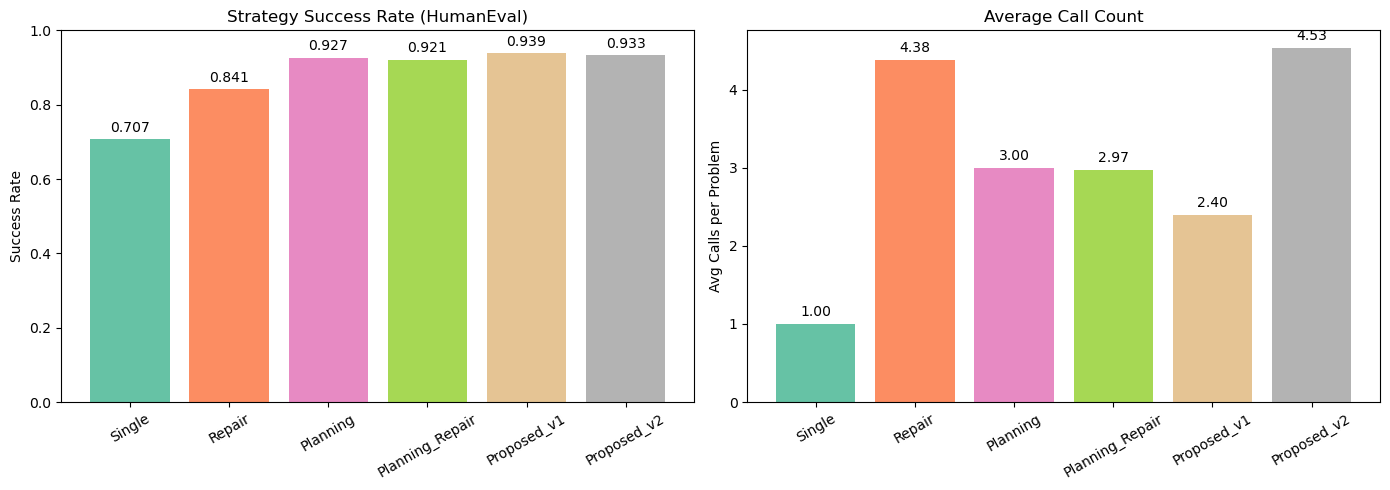

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2a. 성공률
success_rates = {}
for label, df in trajs.items():
    rate = (df['final_status'] == 'PASS').mean()
    success_rates[label] = rate

ax = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(success_rates)))
bars = ax.bar(success_rates.keys(), success_rates.values(), color=colors)
ax.set_ylabel('Success Rate')
ax.set_title('Strategy Success Rate (HumanEval)')
ax.set_ylim(0, 1)
for b, v in zip(bars, success_rates.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=30)

# 2b. 평균 call count
avg_calls = {}
for label, df in trajs.items():
    avg_calls[label] = df['call_count'].mean()

ax = axes[1]
bars = ax.bar(avg_calls.keys(), avg_calls.values(), color=colors)
ax.set_ylabel('Avg Calls per Problem')
ax.set_title('Average Call Count')
for b, v in zip(bars, avg_calls.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Step-level Action 분포

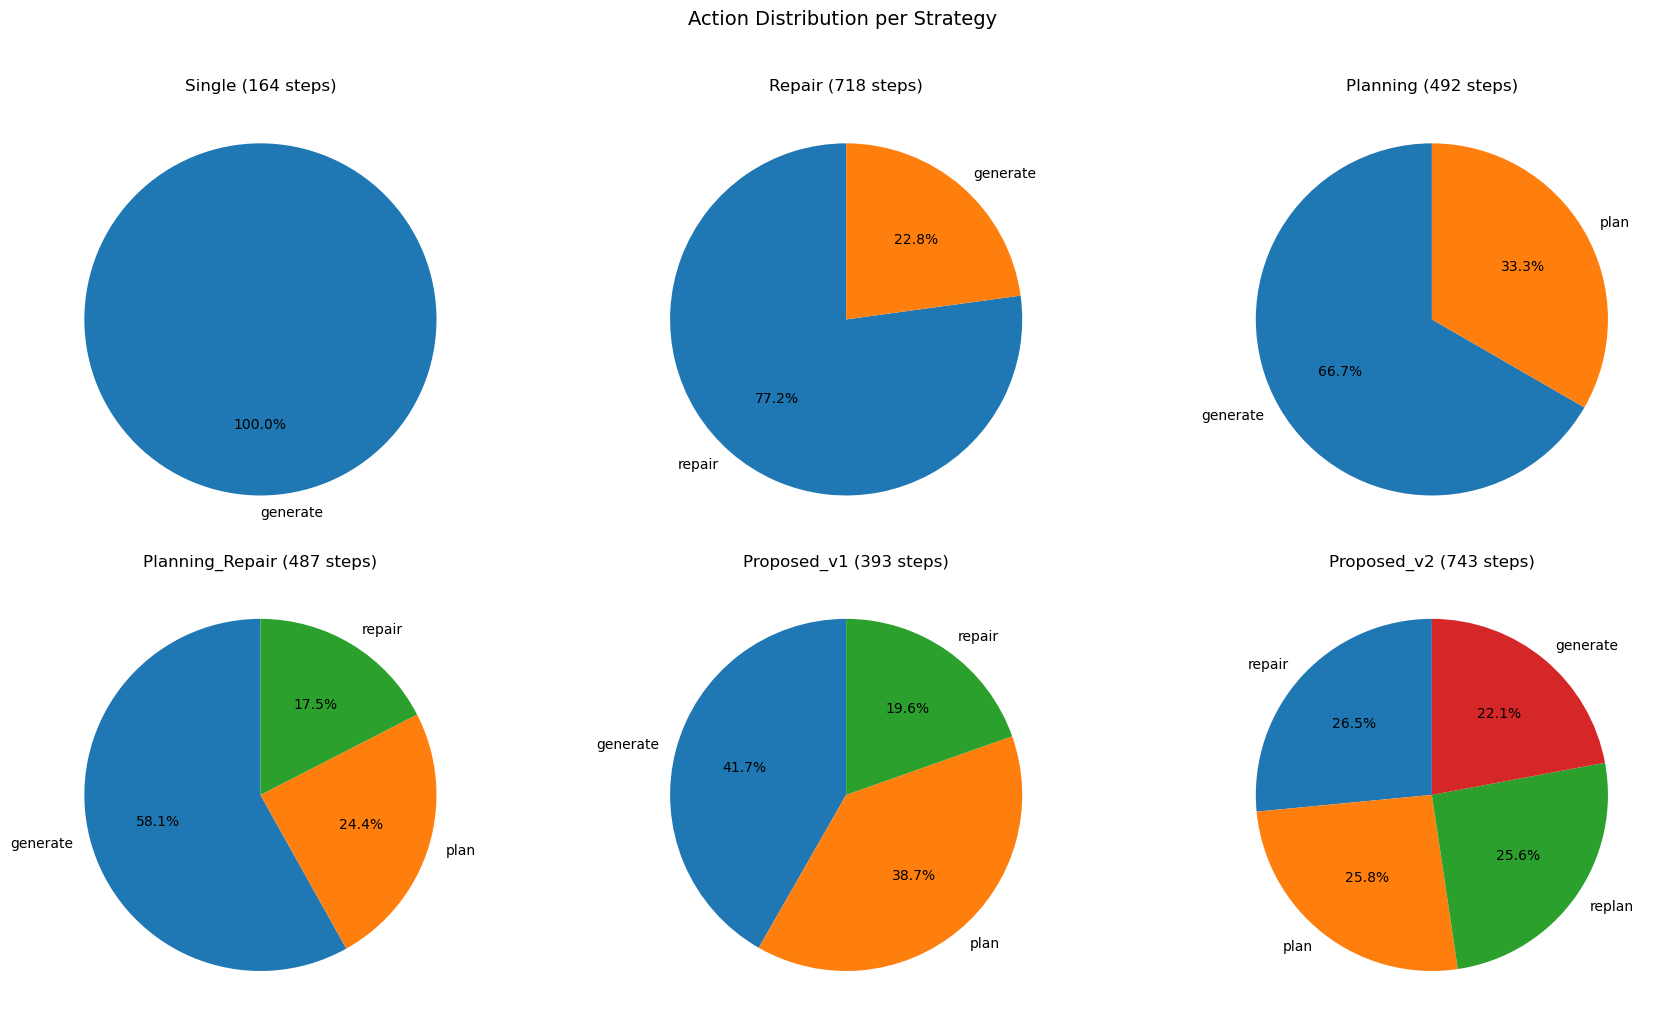

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (label, df) in enumerate(steps.items()):
    ax = axes[i]
    # stage or policy_action
    if 'policy_action' in df.columns:
        col = 'policy_action'
    else:
        col = 'stage'
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{label} ({len(df)} steps)')

plt.suptitle('Action Distribution per Strategy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Step별 성공률 변화 (Cumulative Recovery Curve)
각 step에서의 누적 성공률. repair/plan이 실제로 문제를 해결하는지 확인.

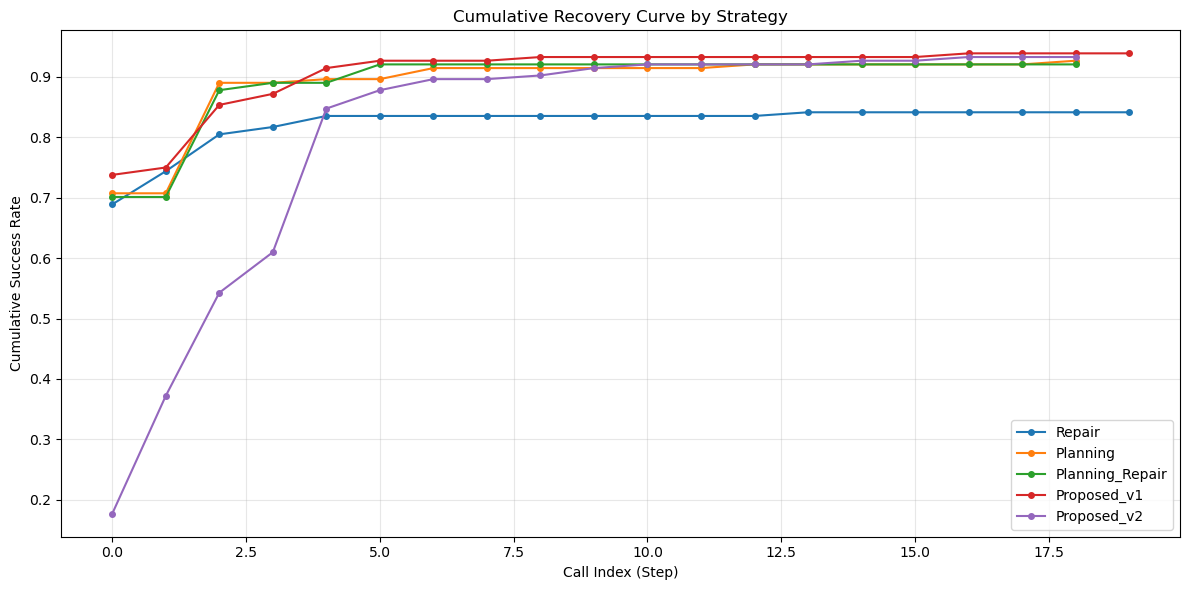

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for label, df in steps.items():
    if label == 'Single':
        continue
    # 각 problem의 각 step에서 최초 PASS가 되는 call_index
    problems = df['problem_id'].unique()
    n_problems = len(problems)
    max_step = df['call_index'].max()
    
    cumulative = []
    for step in range(int(max_step) + 1):
        solved_at_step = 0
        for pid in problems:
            pdf = df[df['problem_id'] == pid]
            passed_steps = pdf[pdf['status'] == 'PASS']['call_index']
            if len(passed_steps) > 0 and passed_steps.min() <= step:
                solved_at_step += 1
        cumulative.append(solved_at_step / n_problems)
    
    ax.plot(range(len(cumulative)), cumulative, marker='o', markersize=4, label=label)

ax.set_xlabel('Call Index (Step)')
ax.set_ylabel('Cumulative Success Rate')
ax.set_title('Cumulative Recovery Curve by Strategy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Transition Path 분석
문제를 풀어가는 status 시퀀스 패턴. 예: `FAIL→FAIL→PASS`, `FAIL→PLAN→PASS`

In [6]:
for label, df in trajs.items():
    if label == 'Single':
        continue
    print(f'\n{"="*60}')
    print(f'  {label} - Top 10 Transition Patterns')
    print(f'{"="*60}')
    
    paths = df['transition_path'].apply(lambda x: ' → '.join(x) if isinstance(x, list) else str(x))
    counts = paths.value_counts().head(10)
    for path, cnt in counts.items():
        final = df[paths == path]['final_status'].iloc[0]
        emoji = '✅' if final == 'PASS' else '❌'
        print(f'  {emoji} [{cnt:>3d}] {path}')


  Repair - Top 10 Transition Patterns
  ✅ [113] PASS
  ✅ [  8] EXEC_FAIL:SyntaxError → EXEC_FAIL:SyntaxError → PASS
  ✅ [  4] TEST_FAIL:AssertionError → PASS
  ❌ [  4] TEST_FAIL:AssertionError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError
  ✅ [  4] EXEC_FAIL:SyntaxError → PASS
  ❌ [  2] EXEC_FAIL:AssertionError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC_FAIL:NameError → EXEC

## 6. 전략별 Recovery 분석
1차 generate 실패 후 최종 성공한 비율

       Strategy  First Fail  Recovered  Recovery Rate
         Repair          51         25       0.490196
       Planning          48         36       0.750000
Planning_Repair          49         36       0.734694
    Proposed_v1          43         33       0.767442
    Proposed_v2         135        124       0.918519


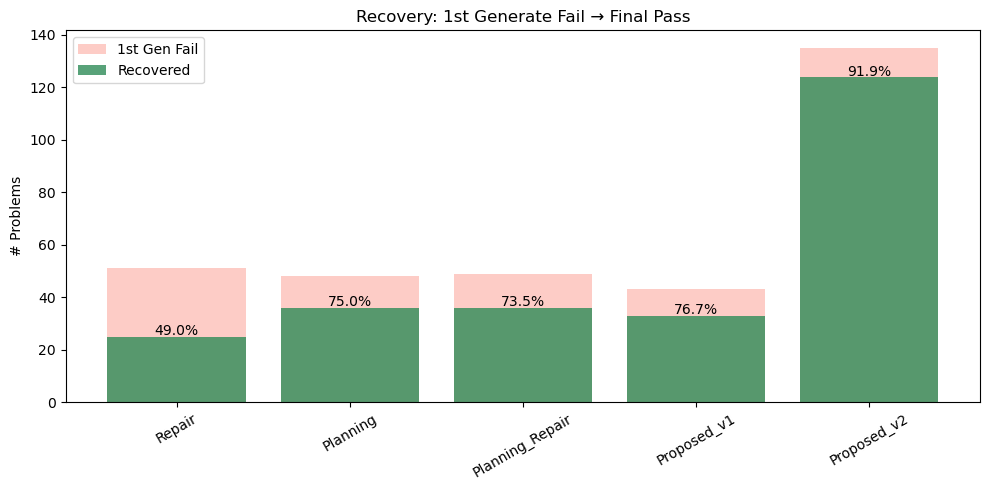

In [7]:
recovery_data = []

for label, sdf in steps.items():
    if label == 'Single':
        continue
    tdf = trajs[label]
    
    # 1차 generate 실패 문제 식별
    first_steps = sdf[sdf['call_index'] == 0]
    first_fail_pids = set(first_steps[first_steps['status'] != 'PASS']['problem_id'])
    
    if len(first_fail_pids) == 0:
        continue
    
    # 그 중 최종 성공한 문제
    final_pass = set(tdf[tdf['final_status'] == 'PASS']['problem_id'])
    recovered = first_fail_pids & final_pass
    
    recovery_data.append({
        'Strategy': label,
        'First Fail': len(first_fail_pids),
        'Recovered': len(recovered),
        'Recovery Rate': len(recovered) / len(first_fail_pids) if first_fail_pids else 0,
    })

rdf = pd.DataFrame(recovery_data)
print(rdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(rdf))
ax.bar(x, rdf['First Fail'], label='1st Gen Fail', alpha=0.4, color='salmon')
ax.bar(x, rdf['Recovered'], label='Recovered', alpha=0.8, color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(rdf['Strategy'], rotation=30)
ax.set_ylabel('# Problems')
ax.set_title('Recovery: 1st Generate Fail → Final Pass')
ax.legend()
for i, row in rdf.iterrows():
    ax.text(i, row['Recovered'] + 0.5, f"{row['Recovery Rate']:.1%}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 7. 토큰 효율성 분석
성공한 문제 vs 실패한 문제에서의 토큰 사용량 비교

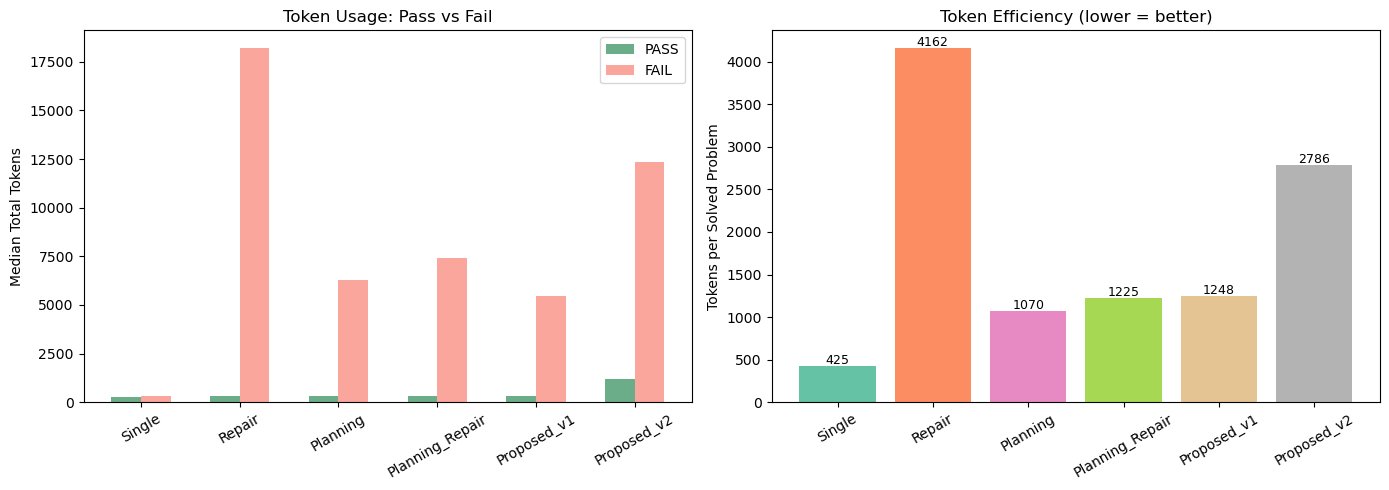

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7a. 성공/실패별 총 토큰
token_data = []
for label, df in trajs.items():
    for _, row in df.iterrows():
        token_data.append({
            'Strategy': label,
            'Status': 'PASS' if row['final_status'] == 'PASS' else 'FAIL',
            'Total Tokens': row['total_tokens'],
            'Call Count': row['call_count'],
        })
tkdf = pd.DataFrame(token_data)

ax = axes[0]
for i, label in enumerate(LABELS):
    sub = tkdf[tkdf['Strategy'] == label]
    pass_tokens = sub[sub['Status'] == 'PASS']['Total Tokens'].median()
    fail_tokens = sub[sub['Status'] == 'FAIL']['Total Tokens'].median()
    ax.bar(i - 0.15, pass_tokens, 0.3, label='PASS' if i == 0 else '', color='seagreen', alpha=0.7)
    ax.bar(i + 0.15, fail_tokens, 0.3, label='FAIL' if i == 0 else '', color='salmon', alpha=0.7)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=30)
ax.set_ylabel('Median Total Tokens')
ax.set_title('Token Usage: Pass vs Fail')
ax.legend()

# 7b. 성공당 토큰 비용
ax = axes[1]
cost_per_success = []
for label, df in trajs.items():
    total_tokens = df['total_tokens'].sum()
    n_pass = (df['final_status'] == 'PASS').sum()
    cost = total_tokens / n_pass if n_pass > 0 else 0
    cost_per_success.append(cost)
bars = ax.bar(LABELS, cost_per_success, color=plt.cm.Set2(np.linspace(0, 1, len(LABELS))))
ax.set_ylabel('Tokens per Solved Problem')
ax.set_title('Token Efficiency (lower = better)')
ax.tick_params(axis='x', rotation=30)
for b, v in zip(bars, cost_per_success):
    ax.text(b.get_x() + b.get_width()/2, v + 20, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. 문제별 교차 비교 (Cross-Strategy Heatmap)
같은 문제에 대해 어느 전략이 풀었는지 매트릭스

=== 문제 난이도 분류 ===
모든 전략 성공: 105
일부만 성공:   54
모두 실패:     5


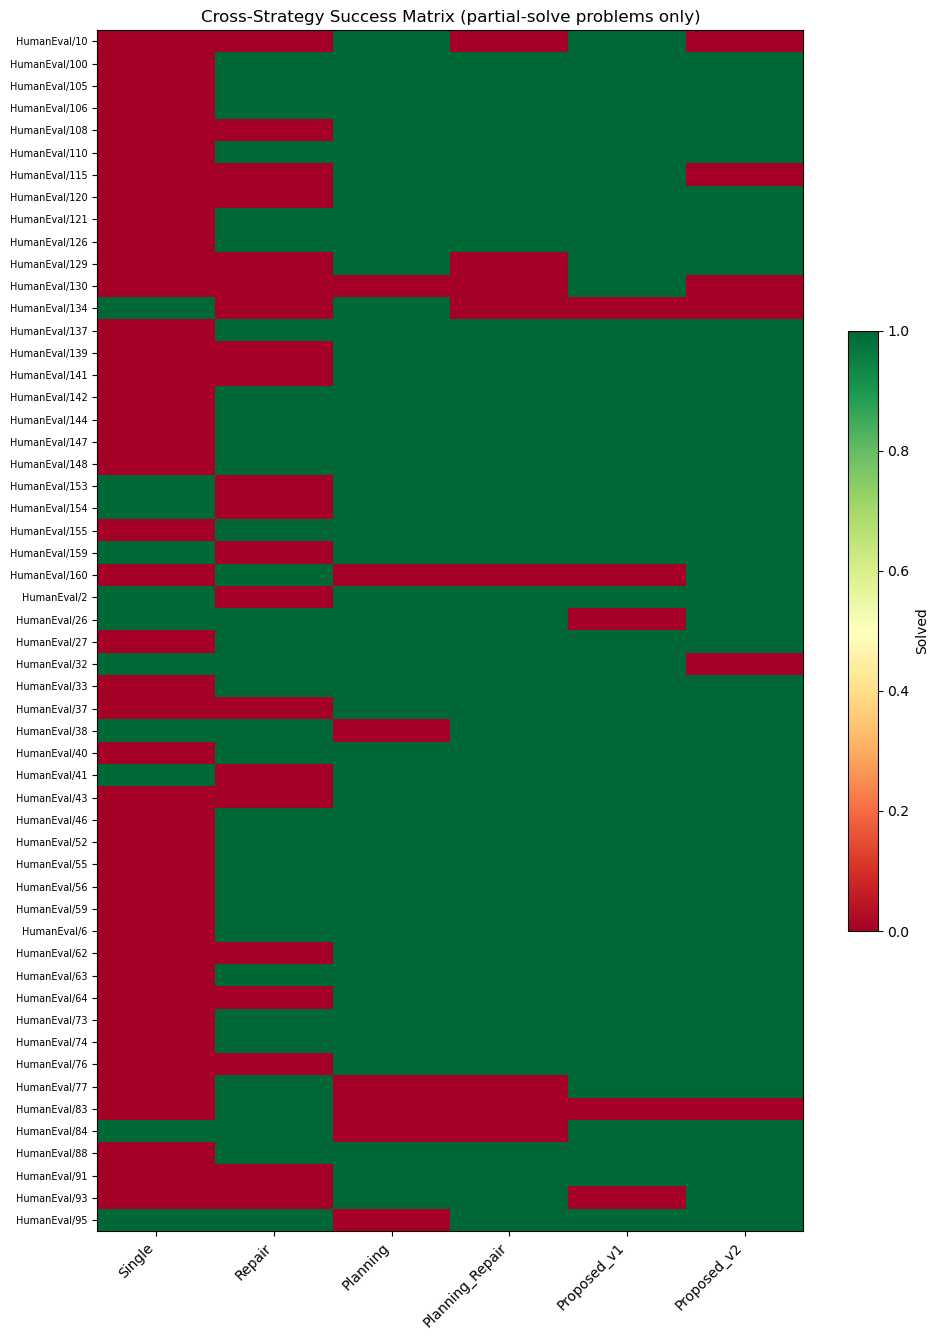

In [9]:
# 문제별 성공 매트릭스
all_pids = sorted(set().union(*[set(df['problem_id']) for df in trajs.values()]))

matrix = pd.DataFrame(index=all_pids)
for label, df in trajs.items():
    pass_set = set(df[df['final_status'] == 'PASS']['problem_id'])
    matrix[label] = [1 if pid in pass_set else 0 for pid in all_pids]

# 요약 통계
matrix['solved_by'] = matrix[list(trajs.keys())].sum(axis=1)
print('=== 문제 난이도 분류 ===')
print(f"모든 전략 성공: {(matrix['solved_by'] == len(trajs)).sum()}")
print(f"일부만 성공:   {((matrix['solved_by'] > 0) & (matrix['solved_by'] < len(trajs))).sum()}")
print(f"모두 실패:     {(matrix['solved_by'] == 0).sum()}")

# Heatmap (실패 문제만)
partial = matrix[(matrix['solved_by'] > 0) & (matrix['solved_by'] < len(trajs))]
if len(partial) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(partial) * 0.25)))
    im = ax.imshow(partial[list(trajs.keys())].values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_yticks(range(len(partial)))
    ax.set_yticklabels(partial.index, fontsize=7)
    ax.set_xticks(range(len(trajs)))
    ax.set_xticklabels(list(trajs.keys()), rotation=45, ha='right')
    ax.set_title('Cross-Strategy Success Matrix (partial-solve problems only)')
    plt.colorbar(im, ax=ax, shrink=0.5, label='Solved')
    plt.tight_layout()
    plt.show()

## 9. Action 시퀀스 Sankey 요약
각 전략에서 action 전환 빈도

In [10]:
for label, df in steps.items():
    if label == 'Single':
        continue
    print(f'\n{"="*60}')
    print(f'  {label} - Action Transitions')
    print(f'{"="*60}')
    
    col = 'policy_action' if 'policy_action' in df.columns else 'stage'
    transitions = Counter()
    for pid in df['problem_id'].unique():
        pdf = df[df['problem_id'] == pid].sort_values('call_index')
        actions = pdf[col].tolist()
        for i in range(len(actions) - 1):
            transitions[(actions[i], actions[i+1])] += 1
    
    for (a, b), cnt in transitions.most_common(15):
        print(f'  {a:>15s} → {b:<15s} : {cnt:>4d}')


  Repair - Action Transitions
           repair → repair          :  503
         generate → repair          :   51

  Planning - Action Transitions
         generate → plan            :  164
             plan → generate        :  164

  Planning_Repair - Action Transitions
             plan → generate        :  119
         generate → repair          :   85
           repair → plan            :   70
         generate → plan            :   49

  Proposed_v1 - Action Transitions
             plan → plan            :  111
           repair → repair          :   48
         generate → plan            :   26
         generate → repair          :   17
           repair → plan            :   15
             plan → repair          :   12

  Proposed_v2 - Action Transitions
           replan → replan          :  157
         generate → repair          :  104
             plan → plan            :   96
           repair → repair          :   75
           repair → plan            :   65
       

## 10. 전략 고유 성공 문제 (Unique Solves)

In [11]:
pass_sets = {}
for label, df in trajs.items():
    pass_sets[label] = set(df[df['final_status'] == 'PASS']['problem_id'])

print('=== 전략별 고유 성공 문제 (다른 전략에서는 실패) ===')
for label, pset in pass_sets.items():
    others = set()
    for l2, p2 in pass_sets.items():
        if l2 != label:
            others |= p2
    unique = pset - others
    if unique:
        print(f'\n  {label} ({len(unique)} unique):')
        for pid in sorted(unique):
            print(f'    - {pid}')

=== 전략별 고유 성공 문제 (다른 전략에서는 실패) ===

  Repair (1 unique):
    - HumanEval/83

  Proposed_v1 (1 unique):
    - HumanEval/130
